Problem 1: Divide and Conquer - Merge Sort 

Input Size: 100 | Time Taken: 0.001000 seconds
Input Size: 500 | Time Taken: 0.004000 seconds
Input Size: 1000 | Time Taken: 0.006000 seconds
Input Size: 2000 | Time Taken: 0.011000 seconds
Input Size: 5000 | Time Taken: 0.025000 seconds


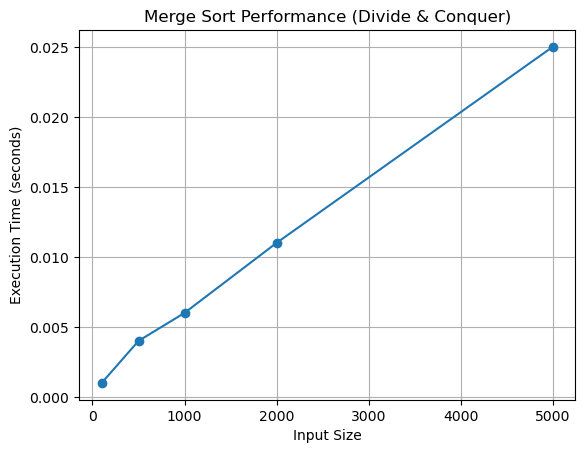

In [2]:
import random
import time
import matplotlib.pyplot as plt

def merge(left, right):
    merged = []
    i = j = 0

    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            merged.append(left[i])
            i += 1
        else:
            merged.append(right[j])
            j += 1

    merged.extend(left[i:])
    merged.extend(right[j:])
    
    return merged

def merge_sort(arr):
    if len(arr) <= 1:
        return arr

    mid = len(arr) // 2

    left_half = merge_sort(arr[:mid])
    right_half = merge_sort(arr[mid:])

    return merge(left_half, right_half)

input_sizes = [100, 500, 1000, 2000, 5000]
execution_times = []

for size in input_sizes:
    arr = [random.randint(1, 10000) for _ in range(size)]

    start_time = time.time()
    sorted_arr = merge_sort(arr)
    end_time = time.time()

    time_taken = end_time - start_time
    execution_times.append(time_taken)

    print(f"Input Size: {size} | Time Taken: {time_taken:.6f} seconds")


plt.plot(input_sizes, execution_times, marker='o')
plt.title("Merge Sort Performance (Divide & Conquer)")
plt.xlabel("Input Size")
plt.ylabel("Execution Time (seconds)")
plt.grid()

plt.show()

Problem 2: Sorting Performance Comparison (Merge Sort and Bubble Sort)

Size: 100 | Bubble: 0.002000s | Merge: 0.001000s
Size: 300 | Bubble: 0.018000s | Merge: 0.003000s
Size: 500 | Bubble: 0.067000s | Merge: 0.004000s
Size: 700 | Bubble: 0.110000s | Merge: 0.005000s
Size: 1000 | Bubble: 0.192000s | Merge: 0.009000s


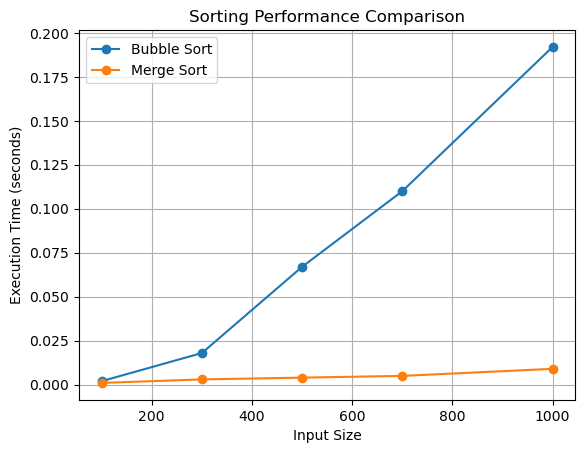

In [3]:

import random
import time
import matplotlib.pyplot as plt

def bubble_sort(arr):
    n = len(arr)
    for i in range(n):
        for j in range(0, n-i-1):
            if arr[j] > arr[j+1]:
                arr[j], arr[j+1] = arr[j+1], arr[j]
    return arr

def merge(left, right):
    merged = []
    i = j = 0

    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            merged.append(left[i])
            i += 1
        else:
            merged.append(right[j])
            j += 1

    merged.extend(left[i:])
    merged.extend(right[j:])
    return merged


def merge_sort(arr):
    if len(arr) <= 1:
        return arr

    mid = len(arr) // 2
    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])
    return merge(left, right)


input_sizes = [100, 300, 500, 700, 1000]

bubble_times = []
merge_times = []

for size in input_sizes:
    arr = [random.randint(1, 10000) for _ in range(size)]

    # Bubble Sort Timing
    arr_copy = arr.copy()
    start = time.time()
    bubble_sort(arr_copy)
    end = time.time()
    bubble_times.append(end - start)

    # Merge Sort Timing
    arr_copy = arr.copy()
    start = time.time()
    merge_sort(arr_copy)
    end = time.time()
    merge_times.append(end - start)

    print(f"Size: {size} | Bubble: {bubble_times[-1]:.6f}s | Merge: {merge_times[-1]:.6f}s")


plt.plot(input_sizes, bubble_times, marker='o', label='Bubble Sort')
plt.plot(input_sizes, merge_times, marker='o', label='Merge Sort')

plt.xlabel("Input Size")
plt.ylabel("Execution Time (seconds)")
plt.title("Sorting Performance Comparison")
plt.legend()
plt.grid()

plt.show()

Problem 3: Greedy Algorithm - Fractional Knapsack

In [4]:
def fractional_knapsack(values, weights, capacity):
    n = len(values)
    
    items = []
    for i in range(n):
        ratio = values[i] / weights[i]
        items.append((ratio, values[i], weights[i]))
    
    items.sort(reverse=True)

    total_value = 0
    selected_items = []

    for ratio, value, weight in items:
        if capacity >= weight:
            # Take full item
            capacity -= weight
            total_value += value
            selected_items.append((value, weight, 1))  # 1 means full item
        else:
            fraction = capacity / weight
            total_value += value * fraction
            selected_items.append((value, weight, fraction))
            break

    return total_value, selected_items

values = [60, 100, 120]
weights = [10, 20, 30]
capacity = 50

max_value, items_taken = fractional_knapsack(values, weights, capacity)

# -------------------------------
# Output
# -------------------------------
print("Maximum Value:", max_value)
print("\nItems taken (value, weight, fraction):")

for item in items_taken:
    print(item)

Maximum Value: 240.0

Items taken (value, weight, fraction):
(60, 10, 1)
(100, 20, 1)
(120, 30, 0.6666666666666666)


Problem 4: Dynamic Programming (0/1 Knapsack)

In [5]:
import time
def knapsack_01(values, weights, capacity):
    n = len(values)

    dp = [[0 for _ in range(capacity + 1)] for _ in range(n + 1)]

    for i in range(1, n + 1):
        for w in range(capacity + 1):
            if weights[i-1] <= w:
                dp[i][w] = max(
                    values[i-1] + dp[i-1][w - weights[i-1]],
                    dp[i-1][w]
                )
            else:
                dp[i][w] = dp[i-1][w]

    return dp[n][capacity], dp

values = [60, 100, 120]
weights = [10, 20, 30]
capacity = 50

start_time = time.time()
max_value, dp_table = knapsack_01(values, weights, capacity)
end_time = time.time()

print("Maximum Value:", max_value)
print("Execution Time:", end_time - start_time, "seconds")

print("\nDP Table:")
for row in dp_table:
    print(row)

Maximum Value: 220
Execution Time: 0.0019998550415039062 seconds

DP Table:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 160, 160, 160, 160, 160, 160, 160, 160, 160, 160, 180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 220]
